# MODULE 1 — Fondements Python pour l'Analyse Géospatiale
## Cours Magistral Interactif

> **Cours** : Analyse Spatiale avec Machine Learning (ASML)  
> **Institut** : 2iE — Master Eau, Environnement, Aménagement  
> **Volume** : CM 1h | TP 2h | Prérequis : Python intermédiaire
> **Enseignant** : Dr Rodrique KAFANDO, Universite Virtuelle (uv.bf) du Burkina Faso, Centre d'Excellence en IA CITADEL (citadel.bf) - kafando.rodrique@gmail.com

---

## Objectifs d'apprentissage du module

Au terme de ce module, vous serez en mesure de :

| # | Objectif | Sections |
|---|---------|---------|
| **OA1** | Décrire le rôle de chaque bibliothèque Python SIG et leurs interdépendances | §2 |
| **OA2** | Charger, explorer et manipuler des données vectorielles (GeoDataFrame) | §3 |
| **OA3** | Ouvrir et lire des données raster avec Rasterio, calculer le NDVI | §4 |
| **OA4** | Comprendre le CRS et reprojeter des données | §5 |
| **OA5** | Produire des cartes statiques et interactives | §6 |
| **OA6** | Appliquer ces outils à des données réelles du Burkina Faso | Transversal |

---

## Comment utiliser ce notebook

| Cellule | Rôle |
|---------|------|
| Markdown avec `OA…` | Théorie liée à un objectif précis |
| Code | Exemple illustratif **exécutable** — pas un exercice |

> Les **exercices** sont dans `M1_TP_Enonce_v2.ipynb`.
> Ce notebook vous permet de **lire la théorie et exécuter les exemples**
> dans le même environnement, en suivant exactement le plan du CM.

## Installation (Google Colab uniquement)

In [1]:
# Décommenter si nécessaire
!pip install geopandas rasterio folium contextily rasterstats --quiet

## Imports

In [2]:
import json, io, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point
import rasterio
from rasterio.transform import from_bounds
from rasterstats import zonal_stats
import folium
import contextily as ctx
import requests

print('Bibliothèques chargées. GeoPandas :', gpd.__version__)

# ═══════════════════════════════════════════════════════════════
# Données fallback embarquées — définies EN PREMIER
# (avant la fonction load_gadm_regions pour éviter tout NameError)
# ═══════════════════════════════════════════════════════════════

GJ_REG_STR = '{"type": "FeatureCollection", "features": [{"type": "Feature", "properties": {"region": "Boucle du Mouhoun", "chef_lieu": "Dédougou", "population": 1427000}, "geometry": {"type": "Polygon", "coordinates": [[[-3.45, 12.15], [-2.3499999999999996, 12.15], [-2.3499999999999996, 13.049999999999999], [-3.45, 13.049999999999999], [-3.45, 12.15]]]}}, {"type": "Feature", "properties": {"region": "Cascades", "chef_lieu": "Banfora", "population": 730000}, "geometry": {"type": "Polygon", "coordinates": [[[-5.0, 10.05], [-3.9000000000000004, 10.05], [-3.9000000000000004, 10.95], [-5.0, 10.95], [-5.0, 10.05]]]}}, {"type": "Feature", "properties": {"region": "Centre", "chef_lieu": "Ouagadougou", "population": 2415000}, "geometry": {"type": "Polygon", "coordinates": [[[-2.0700000000000003, 11.91], [-0.97, 11.91], [-0.97, 12.809999999999999], [-2.0700000000000003, 12.809999999999999], [-2.0700000000000003, 11.91]]]}}, {"type": "Feature", "properties": {"region": "Centre-Est", "chef_lieu": "Tenkodogo", "population": 1430000}, "geometry": {"type": "Polygon", "coordinates": [[[-0.35000000000000003, 11.4], [0.75, 11.4], [0.75, 12.299999999999999], [-0.35000000000000003, 12.299999999999999], [-0.35000000000000003, 11.4]]]}}, {"type": "Feature", "properties": {"region": "Centre-Nord", "chef_lieu": "Kaya", "population": 1400000}, "geometry": {"type": "Polygon", "coordinates": [[[-1.6, 12.600000000000001], [-0.5, 12.600000000000001], [-0.5, 13.5], [-1.6, 13.5], [-1.6, 12.600000000000001]]]}}, {"type": "Feature", "properties": {"region": "Centre-Ouest", "chef_lieu": "Koudougou", "population": 1360000}, "geometry": {"type": "Polygon", "coordinates": [[[-3.0, 11.65], [-1.9000000000000001, 11.65], [-1.9000000000000001, 12.549999999999999], [-3.0, 12.549999999999999], [-3.0, 11.65]]]}}, {"type": "Feature", "properties": {"region": "Centre-Sud", "chef_lieu": "Manga", "population": 730000}, "geometry": {"type": "Polygon", "coordinates": [[[-1.6, 11.05], [-0.5, 11.05], [-0.5, 11.95], [-1.6, 11.95], [-1.6, 11.05]]]}}, {"type": "Feature", "properties": {"region": "Est", "chef_lieu": "Fada N\'Gourma", "population": 1580000}, "geometry": {"type": "Polygon", "coordinates": [[[0.8, 11.65], [1.9000000000000001, 11.65], [1.9000000000000001, 12.549999999999999], [0.8, 12.549999999999999], [0.8, 11.65]]]}}, {"type": "Feature", "properties": {"region": "Hauts-Bassins", "chef_lieu": "Bobo-Dioulasso", "population": 2040000}, "geometry": {"type": "Polygon", "coordinates": [[[-4.8, 10.700000000000001], [-3.7, 10.700000000000001], [-3.7, 11.6], [-4.8, 11.6], [-4.8, 10.700000000000001]]]}}, {"type": "Feature", "properties": {"region": "Nord", "chef_lieu": "Ouahigouya", "population": 1110000}, "geometry": {"type": "Polygon", "coordinates": [[[-2.9699999999999998, 13.13], [-1.8699999999999999, 13.13], [-1.8699999999999999, 14.03], [-2.9699999999999998, 14.03], [-2.9699999999999998, 13.13]]]}}, {"type": "Feature", "properties": {"region": "Plateau Central", "chef_lieu": "Ziniaré", "population": 790000}, "geometry": {"type": "Polygon", "coordinates": [[[-1.17, 12.100000000000001], [-0.06999999999999995, 12.100000000000001], [-0.06999999999999995, 13.0], [-1.17, 13.0], [-1.17, 12.100000000000001]]]}}, {"type": "Feature", "properties": {"region": "Sahel", "chef_lieu": "Dori", "population": 1230000}, "geometry": {"type": "Polygon", "coordinates": [[[-0.6000000000000001, 13.600000000000001], [0.5, 13.600000000000001], [0.5, 14.5], [-0.6000000000000001, 14.5], [-0.6000000000000001, 13.600000000000001]]]}}, {"type": "Feature", "properties": {"region": "Sud-Ouest", "chef_lieu": "Diébougou", "population": 730000}, "geometry": {"type": "Polygon", "coordinates": [[[-3.8, 10.15], [-2.7, 10.15], [-2.7, 11.049999999999999], [-3.8, 11.049999999999999], [-3.8, 10.15]]]}}]}'

fallback_gdf = gpd.GeoDataFrame.from_features(
    json.loads(GJ_REG_STR)['features'], crs='EPSG:4326'
)

GJ_EAU_STR = '{"type": "FeatureCollection", "features": [{"type": "Feature", "properties": {"nom": "PEA-001", "type": "Forage"}, "geometry": {"type": "Point", "coordinates": [-2.8, 12.7]}}, {"type": "Feature", "properties": {"nom": "PEA-002", "type": "Puits"}, "geometry": {"type": "Point", "coordinates": [-2.5, 12.5]}}, {"type": "Feature", "properties": {"nom": "PEA-003", "type": "Forage"}, "geometry": {"type": "Point", "coordinates": [-4.3, 10.6]}}, {"type": "Feature", "properties": {"nom": "PEA-004", "type": "Forage"}, "geometry": {"type": "Point", "coordinates": [-1.55, 12.38]}}, {"type": "Feature", "properties": {"nom": "PEA-005", "type": "Puits"}, "geometry": {"type": "Point", "coordinates": [-1.48, 12.32]}}, {"type": "Feature", "properties": {"nom": "PEA-006", "type": "Forage"}, "geometry": {"type": "Point", "coordinates": [0.1, 11.9]}}, {"type": "Feature", "properties": {"nom": "PEA-007", "type": "Forage"}, "geometry": {"type": "Point", "coordinates": [-1.1, 13.1]}}, {"type": "Feature", "properties": {"nom": "PEA-008", "type": "Puits"}, "geometry": {"type": "Point", "coordinates": [-0.95, 12.95]}}, {"type": "Feature", "properties": {"nom": "PEA-009", "type": "Forage"}, "geometry": {"type": "Point", "coordinates": [-2.55, 12.2]}}, {"type": "Feature", "properties": {"nom": "PEA-010", "type": "Puits"}, "geometry": {"type": "Point", "coordinates": [-1.0, 11.55]}}, {"type": "Feature", "properties": {"nom": "PEA-011", "type": "Forage"}, "geometry": {"type": "Point", "coordinates": [1.3, 12.2]}}, {"type": "Feature", "properties": {"nom": "PEA-012", "type": "Puits"}, "geometry": {"type": "Point", "coordinates": [1.5, 11.9]}}, {"type": "Feature", "properties": {"nom": "PEA-013", "type": "Forage"}, "geometry": {"type": "Point", "coordinates": [-4.2, 11.2]}}, {"type": "Feature", "properties": {"nom": "PEA-014", "type": "Puits"}, "geometry": {"type": "Point", "coordinates": [-4.4, 11.0]}}, {"type": "Feature", "properties": {"nom": "PEA-015", "type": "Forage"}, "geometry": {"type": "Point", "coordinates": [-2.45, 13.65]}}, {"type": "Feature", "properties": {"nom": "PEA-016", "type": "Forage"}, "geometry": {"type": "Point", "coordinates": [-0.1, 14.1]}}, {"type": "Feature", "properties": {"nom": "PEA-017", "type": "Forage"}, "geometry": {"type": "Point", "coordinates": [-3.3, 10.65]}}, {"type": "Feature", "properties": {"nom": "PEA-018", "type": "Puits"}, "geometry": {"type": "Point", "coordinates": [-1.8, 12.55]}}]}'

puits = gpd.GeoDataFrame.from_features(
    json.loads(GJ_EAU_STR)['features'], crs='EPSG:4326'
)

print(f'Fallback : {len(fallback_gdf)} régions + {len(puits)} points d\'eau')

# ═══════════════════════════════════════════════════════════════
# Chargement GADM 4.1 — 13 vraies régions BF
# Source : https://gadm.org/download_country.html → GeoJSON level-1
# URL    : geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_BFA_1.json
# Si GADM inaccessible → fallback automatique (aucune action requise)
# ═══════════════════════════════════════════════════════════════

URL_GADM_L1 = 'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_BFA_1.json'

def load_gadm_regions(fallback):
    try:
        print('Chargement GADM level-1 (vraies géométries BF)...')
        r = requests.get(URL_GADM_L1, timeout=15)
        r.raise_for_status()
        gdf_raw = gpd.read_file(io.BytesIO(r.content))
        gdf_raw = gdf_raw.rename(columns={
            'NAME_0':'pays', 'NAME_1':'region', 'GID_1':'gid_region'
        })
        # Récupérer chef_lieu + population depuis le fallback si absents dans GADM
        for col in ['chef_lieu','population','superficie_ref']:
            if col in fallback.columns and col not in gdf_raw.columns:
                mapping = fallback.set_index('region')[col].to_dict()
                gdf_raw[col] = gdf_raw['region'].map(mapping)
        print(f'[GADM ✅] {len(gdf_raw)} régions | CRS: {gdf_raw.crs}')
        return gdf_raw, 'GADM 4.1'
    except Exception as e:
        warnings.warn(f'GADM inaccessible ({e}) → fallback', stacklevel=2)
        print('[FALLBACK ⚠️] Rectangles embarqués utilisés')
        return fallback.copy(), 'fallback'

gdf, source_gdf = load_gadm_regions(fallback_gdf)

print(f'\nSource  : {source_gdf}')
print(f'Régions : {len(gdf)} | CRS : {gdf.crs}')


Bibliothèques chargées. GeoPandas : 1.1.3
Fallback : 13 régions + 18 points d'eau
Chargement GADM level-1 (vraies géométries BF)...
[GADM ✅] 13 régions | CRS: EPSG:4326

Source  : GADM 4.1
Régions : 13 | CRS : EPSG:4326


## Données utilisées dans ce notebook

Ce notebook utilise des données **embarquées** représentant le Burkina Faso :
13 régions administratives et 18 points d'eau (forages et puits).
Ces données sont identiques à celles des TP.

---
# §1 — De la carte cliquée à la carte codée

> *Ce cours ne remplace pas la connaissance du SIG — il la prolonge.*
> *Comprendre ce qu'est une projection, une couche vecteur ou un raster*
> *reste indispensable. Mais désormais, vous allez exprimer cette*
> *connaissance en code Python plutôt qu'en clics de souris.*

**Pourquoi Python plutôt que QGIS ?**

| Critère | QGIS / ArcGIS | Python |
|---------|--------------|--------|
| Reproductibilité | Difficile (clics manuels) | Totale (script exécutable) |
| Automatisation | Limitée | Illimitée |
| Intégration ML | Non | Directe (scikit-learn, etc.) |
| Auditabilité | Difficile | Code lisible et versionnable |

> Un script qui calcule le NDVI moyen des 13 régions du Burkina Faso
> s'exécute en quelques secondes et produit **exactement le même résultat**
> à chaque exécution — quel que soit l'ordinateur.

---
# §2 — L'Écosystème Python SIG

> 🎯 **OA1** — Décrire le rôle de chaque bibliothèque et leurs interdépendances.

## 2.1 Architecture : du bas niveau au haut niveau

```
┌─────────────────────────────────────────────┐
│  Folium · Contextily · Matplotlib           │  ← Visualisation
├─────────────────────────────────────────────┤
│  GeoPandas · Rasterio · rasterstats         │  ← Manipulation
├─────────────────────────────────────────────┤
│  Shapely · PyProj · NumPy                   │  ← Calcul
├─────────────────────────────────────────────┤
│  GDAL (C)                                   │  ← Lecture/écriture fichiers
└─────────────────────────────────────────────┘
```

## 2.2 Rôle de chaque bibliothèque

| Bibliothèque | Rôle | Ce qu'elle fait en pratique |
|-------------|------|-----------------------------|
| **GDAL** | Fondation | Lit/écrit 200+ formats spatiaux. Jamais utilisé directement. |
| **Shapely** | Géométries pures | Calcule buffer, intersection, distance. Moteur de GeoPandas. |
| **PyProj** | Projections / CRS | Convertit des coordonnées entre systèmes. Intégré dans `.to_crs()`. |
| **GeoPandas** | Données vectorielles | GeoDataFrame = DataFrame + colonne geometry. Jointures spatiales, filtres. |
| **Rasterio** | Données raster | Ouvre GeoTIFF, lit bandes, gère la géoréférence. |
| **rasterstats** | Pont vecteur/raster | Calcule des statistiques raster dans des polygones. |
| **Matplotlib** | Cartes statiques | `.plot()` rapide pour diagnostic et livrables imprimés. |
| **Contextily** | Fonds de carte | Ajoute des tuiles OSM derrière un GeoDataFrame. |
| **Folium** | Cartes interactives | Génère du HTML Leaflet.js. Idéal pour les décideurs non-techniciens. |

## 2.3 Comment les bibliothèques s'enchaînent

> Exemple de pipeline complet :
> `GADM (fichier)` → `GeoPandas (charge)` → `PyProj (reprojette)` →
> `Rasterio + rasterstats (extrait NDVI)` → `Matplotlib + Folium (visualise)`

In [3]:
# OA1 — Vérifier que toutes les bibliothèques sont bien importées et opérationnelles
libs = {
    'geopandas': gpd.__version__,
    'rasterio':  rasterio.__version__,
    'numpy':     np.__version__,
    'pandas':    pd.__version__,
}
print('=== Bibliothèques disponibles ===')
for lib, ver in libs.items():
    print(f'  {lib:<15} v{ver}')

# Vérifier que Shapely (moteur de GeoPandas) est actif
from shapely.geometry import Point, Polygon
pt = Point(-1.52, 12.36)  # Ouagadougou
print(f'\nShapely OK — Point test : {pt}')
print(f'Géométrie valide : {pt.is_valid}')

=== Bibliothèques disponibles ===
  geopandas       v1.1.3
  rasterio        v1.5.0
  numpy           v2.0.2
  pandas          v2.2.2

Shapely OK — Point test : POINT (-1.52 12.36)
Géométrie valide : True


---
# §3 — Données Vectorielles avec GeoPandas

> 🎯 **OA2** — Charger, explorer et manipuler des données vectorielles (GeoDataFrame).
> 🎯 **OA6** — Appliqué aux 13 régions administratives du Burkina Faso.

## 3.1 Le GeoDataFrame — concept clé

Un **GeoDataFrame** est un DataFrame Pandas augmenté d'une colonne spéciale `geometry`
qui stocke des formes géographiques (points, lignes, polygones).

```
GeoDataFrame = DataFrame ordinaire + colonne geometry
                                              ↓
                          Point / LineString / Polygon
```

> **Règle d'or** : après tout chargement, vérifier systématiquement :
> `shape` · `crs` · `dtypes` · `geometry.geom_type.value_counts()`
> Ces 4 contrôles en 30 secondes évitent des heures de débogage.

In [4]:
# OA2 + OA6 — Chargement et exploration du GeoDataFrame des régions BF

# Vérifications de base — toujours commencer par là
print('=== Exploration du GeoDataFrame ===')
print(f'Shape     : {gdf.shape}  (13 régions, {gdf.shape[1]} colonnes)')
print(f'CRS       : {gdf.crs}')
print(f'Colonnes  : {list(gdf.columns)}')
print(f'Géom type : {gdf.geometry.geom_type.value_counts().to_dict()}')
print()
print('--- 3 premières lignes ---')
print(gdf[['region','chef_lieu','population','geometry']].head(3).to_string())

=== Exploration du GeoDataFrame ===
Shape     : (13, 14)  (13 régions, 14 colonnes)
CRS       : EPSG:4326
Colonnes  : ['gid_region', 'GID_0', 'COUNTRY', 'region', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry', 'chef_lieu', 'population']
Géom type : {'MultiPolygon': 13}

--- 3 premières lignes ---
            region    chef_lieu  population                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## 3.2 Formats de fichiers spatiaux

GeoPandas lit tous les formats via GDAL :

| Format | Extension | Usage |
|--------|-----------|-------|
| GeoJSON | `.geojson` | Web, API, échange — texte lisible |
| Shapefile | `.shp` + `.dbf` + `.shx` + `.prj` | Format historique ESRI |
| GeoPackage | `.gpkg` | Préférable au shapefile — un seul fichier |

> ⚠️ Un shapefile n'est jamais un seul fichier. Il faut toujours
> déplacer les 4 fichiers ensemble (`.shp`, `.dbf`, `.shx`, `.prj`).
> Préférez le GeoPackage qui ne souffre pas de ce défaut.

In [5]:
# OA2 — Attributs géométriques de base
# ATTENTION : ces calculs nécessitent un CRS métrique (voir §5)
# On les fait d'abord en degrés pour MONTRER l'erreur, puis on corrige

print('=== Superficies en degrés² (INCORRECT) ===')
print(f'Superficie moyenne : {gdf.geometry.area.mean():.4f} degrés² — absurde !')

# Correction : reprojeter en UTM 30N d'abord (expliqué en §5)
gdf_utm = gdf.to_crs(epsg=32630)
print(f'\n=== Superficies en km² (CORRECT, après to_crs 32630) ===')
gdf['superficie_km2'] = gdf_utm.geometry.area / 1e6
gdf['centroid_lon']   = gdf.geometry.centroid.x
gdf['centroid_lat']   = gdf.geometry.centroid.y
print(gdf[['region','superficie_km2']].sort_values('superficie_km2', ascending=False).to_string(index=False))

=== Superficies en degrés² (INCORRECT) ===
Superficie moyenne : 1.7450 degrés² — absurde !

=== Superficies en km² (CORRECT, après to_crs 32630) ===
         region  superficie_km2
            Est    46746.674527
          Sahel    36200.275169
BoucleduMouhoun    34524.734363
   Haut-Bassins    25616.512744
   Centre-Ouest    21377.513523
    Centre-Nord    19678.720239
       Cascades    18572.999581
      Sud-Ouest    16406.588442
           Nord    16404.388320
     Centre-Est    14669.372127
     Centre-Sud    11476.860834
Plateau-Central     8604.346865
         Centre     2868.844470


/tmp/ipykernel_1334/380488970.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f'Superficie moyenne : {gdf.geometry.area.mean():.4f} degrés² — absurde !')
/tmp/ipykernel_1334/380488970.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid_lon']   = gdf.geometry.centroid.x
/tmp/ipykernel_1334/380488970.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid_lat']   = gdf.geometry.centroid.y


## 3.3 Jointures spatiales avec `gpd.sjoin`

> 🎯 **OA2** — La jointure spatiale est l'opération la plus puissante de GeoPandas :
> associer des entités en fonction de leur **relation géographique**
> (contains, within, intersects) plutôt que d'un identifiant commun.

**Scénario** : quelle région contient chaque point d'eau ?
Sans `sjoin`, on devrait tester manuellement chaque paire — O(n×m) opérations.
Avec `sjoin`, une seule ligne de code — optimisé par un index spatial.

> ⚠️ Les deux GeoDataFrames **doivent avoir le même CRS** avant `sjoin`.
> Un CRS différent produit des résultats silencieusement faux.

In [6]:
# OA2 + OA6 — Jointure spatiale : quelle région contient chaque point d'eau ?

# Pré-requis : même CRS
print(f'CRS régions : {gdf.crs}')
print(f'CRS puits   : {puits.crs}')
print(f'Identiques  : {gdf.crs == puits.crs}')

# Jointure spatiale
joined = gpd.sjoin(puits, gdf, how='left', predicate='within')
print(f'\nPoints joints : {joined["region"].notna().sum()}/{len(puits)}')

# Compter les points d'eau par région
nb_peau = joined.groupby('region')['nom'].count().reset_index()
nb_peau.columns = ['region', 'nb_points_eau']
gdf = gdf.merge(nb_peau, on='region', how='left')
gdf['nb_points_eau'] = gdf['nb_points_eau'].fillna(0).astype(int)

print('\n=== Points d\'eau par région ===')
print(gdf[['region','nb_points_eau']].sort_values('nb_points_eau',ascending=False).to_string(index=False))

# Interprétation
print('\n→ Centre (Ouagadougou) : forte densité de points — pression urbaine.')
print('→ Sahel : peu de points d\'eau malgré les besoins — vulnérabilité hydraulique.')

CRS régions : EPSG:4326
CRS puits   : EPSG:4326
Identiques  : True

Points joints : 18/18

=== Points d'eau par région ===
         region  nb_points_eau
            Est              3
    Centre-Nord              2
   Haut-Bassins              2
   Centre-Ouest              2
         Centre              2
           Nord              1
       Cascades              1
BoucleduMouhoun              1
     Centre-Sud              1
          Sahel              1
Plateau-Central              1
      Sud-Ouest              1
     Centre-Est              0

→ Centre (Ouagadougou) : forte densité de points — pression urbaine.
→ Sahel : peu de points d'eau malgré les besoins — vulnérabilité hydraulique.


---
# §4 — Données Raster avec Rasterio

> 🎯 **OA3** — Ouvrir et lire des données raster avec Rasterio, calculer le NDVI.
> 🎯 **OA6** — Appliqué à un raster NDVI synthétique du Burkina Faso.

## 4.1 Qu'est-ce qu'un raster ?

Un raster est une **grille régulière de pixels**, chaque pixel portant une valeur numérique.
Une image Sentinel-2, une carte d'altitude (DEM) ou une estimation de pluviométrie
CHIRPS sont tous des rasters. La différence avec une image photo :
chaque pixel est **géoréférencé** — on sait exactement à quelle portion de la Terre il correspond.

## 4.2 Lire un raster avec Rasterio

> Rasterio gère les rasters comme un livre : on l'**ouvre**, on lit les **pages** (bandes),
> puis on le **ferme**. Le pattern recommandé est le gestionnaire de contexte `with`.

> ⚠️ Les indices de bandes Rasterio commencent à **1**, pas à 0.
> `src.read(1)` = première bande. `src.read(0)` lève une IndexError.

In [7]:
# OA3 + OA6 — Créer un raster NDVI synthétique pour le Burkina Faso
# (reproduit le gradient sahélien N-S : aride au Nord, végétation au Sud)

BBOX_BF = (-5.5, 9.4, 2.4, 15.1)  # (west, south, east, north)
ROWS, COLS = 100, 130
RASTER_PATH = 'bf_ndvi_cm.tif'

lats = np.linspace(BBOX_BF[3], BBOX_BF[1], ROWS)
lons = np.linspace(BBOX_BF[0], BBOX_BF[2], COLS)
LON, LAT = np.meshgrid(lons, lats)

# Gradient latitudinal + bruit réaliste
np.random.seed(42)
ndvi = np.clip(0.62 - (LAT - 9.4) * 0.09 + np.random.normal(0, 0.04, (ROWS, COLS)),
               -0.1, 0.9).astype(np.float32)

# Écriture GeoTIFF
transform = from_bounds(*BBOX_BF, width=COLS, height=ROWS)
profile = {'driver':'GTiff','dtype':rasterio.float32,
           'width':COLS,'height':ROWS,'count':1,
           'crs':'EPSG:4326','transform':transform,'nodata':-9999.0}
with rasterio.open(RASTER_PATH, 'w', **profile) as dst:
    dst.write(ndvi, 1)  # bande 1 — indices commencent à 1 !

print(f'Raster créé : {RASTER_PATH}')
print(f'Dimensions  : {ROWS} × {COLS} pixels')
print(f'NDVI : min={ndvi.min():.3f} | max={ndvi.max():.3f} | moy={ndvi.mean():.3f}')

Raster créé : bf_ndvi_cm.tif
Dimensions  : 100 × 130 pixels
NDVI : min=-0.012 | max=0.741 | moy=0.363


In [10]:
# OA3 — Lire le raster avec Rasterio et inspecter les métadonnées

with rasterio.open(RASTER_PATH) as src:
    print('=== Métadonnées du raster ===')
    print(f'CRS        : {src.crs}')
    print(f'Résolution : {src.res}  (degrés/pixel)')
    print(f'Dimensions : {src.height} × {src.width} pixels')
    print(f'Nb bandes  : {src.count}')
    print(f'NoData     : {src.nodata}')
    print()

    # Lecture de la bande 1 — toujours convertir en float avant calcul !
    ndvi_lu = src.read(1).astype(float)  # .astype(float) = critique

print('=== Démonstration erreur astype(float) ===')
a = np.array([100], dtype=np.uint16)  # bandes Sentinel-2 = uint16
b = np.array([300], dtype=np.uint16)
print(f'Division entière (uint16) : (b-a)/(b+a) = {((b-a)/(b+a))[0]}  ← FAUX')
print(f'Division float            : {((b.astype(float)-a.astype(float))/(b.astype(float)+a.astype(float)))[0]:.3f}  ← CORRECT')
print('→ Sans .astype(float), le NDVI serait 0 ou 1 partout — erreur silencieuse !')

=== Métadonnées du raster ===
CRS        : EPSG:4326
Résolution : (0.06076923076923077, 0.056999999999999995)  (degrés/pixel)
Dimensions : 100 × 130 pixels
Nb bandes  : 1
NoData     : -9999.0

=== Démonstration erreur astype(float) ===
Division entière (uint16) : (b-a)/(b+a) = 0.5  ← FAUX
Division float            : 0.500  ← CORRECT
→ Sans .astype(float), le NDVI serait 0 ou 1 partout — erreur silencieuse !


## 4.3 Calcul du NDVI

**NDVI** (Normalized Difference Vegetation Index) = indice de végétation le plus utilisé.

$$NDVI = \frac{NIR - Rouge}{NIR + Rouge}$$

- Varie de **−1 à +1**
- Valeurs typiques Sahel BF : **0.05** (désert) → **0.60** (savane dense en saison des pluies)

| NDVI | Classe | Contexte BF |
|------|--------|-------------|
| < 0 | Eau, nuages | Mares, fleuve Mouhoun |
| 0.0–0.1 | Sol nu | Sahel dégradé (Oudalan, Séno) |
| 0.1–0.3 | Végétation éparse | Savane sèche, jachères |
| 0.3–0.6 | Végétation modérée | Savane arbustive soudanienne |

In [11]:
# OA3 + OA6 — Calcul NDVI par région via rasterstats
# rasterstats fait le 'pont' entre vecteur (GeoDataFrame) et raster (GeoTIFF)

stats = zonal_stats(gdf, RASTER_PATH, stats=['mean','min','max'], nodata=-9999.0)
gdf['ndvi_mean'] = [s['mean'] for s in stats]
gdf['ndvi_min']  = [s['min']  for s in stats]
gdf['ndvi_max']  = [s['max']  for s in stats]

print('=== NDVI moyen par région (du plus aride au plus vert) ===')
print(gdf[['region','ndvi_mean','ndvi_min','ndvi_max']]
        .sort_values('ndvi_mean')
        .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

print()
print('→ Sahel (Dori) : NDVI le plus faible — aridité sahélienne confirmée.')
print('→ Cascades (Banfora) : NDVI le plus élevé — zone soudanienne humide.')
print('→ Ce gradient N-S du NDVI sera la base du feature engineering en Module 2.')

=== NDVI moyen par région (du plus aride au plus vert) ===
         region  ndvi_mean  ndvi_min  ndvi_max
          Sahel      0.192     0.027     0.375
           Nord      0.253     0.091     0.428
    Centre-Nord      0.273     0.125     0.459
BoucleduMouhoun      0.334     0.137     0.514
Plateau-Central      0.346     0.232     0.495
         Centre      0.358     0.256     0.452
            Est      0.364     0.159     0.548
   Centre-Ouest      0.403     0.216     0.569
     Centre-Est      0.423     0.242     0.552
     Centre-Sud      0.425     0.260     0.533
   Haut-Bassins      0.444     0.269     0.587
      Sud-Ouest      0.526     0.364     0.693
       Cascades      0.535     0.412     0.695

→ Sahel (Dori) : NDVI le plus faible — aridité sahélienne confirmée.
→ Cascades (Banfora) : NDVI le plus élevé — zone soudanienne humide.
→ Ce gradient N-S du NDVI sera la base du feature engineering en Module 2.


---
# §5 — Systèmes de Référence de Coordonnées (CRS)

> 🎯 **OA4** — Comprendre la notion de CRS et reprojeter des données.

## 5.1 Pourquoi le CRS est-il critique ?

La confusion entre systèmes de référence est la **cause numéro un** d'erreurs
silencieuses en géospatial. Deux couches dans des CRS différents semblent
s'afficher correctement, mais toute opération entre elles produit des résultats
**faux sans aucun message d'erreur**.

## 5.2 Les deux grandes familles

| Famille | Exemple | Unité | Usage |
|---------|---------|-------|-------|
| **Géographique** | EPSG:4326 (WGS84) | Degrés | Stockage, échange, Folium |
| **Projeté** | EPSG:32630 (UTM 30N) | Mètres | **Tout calcul métrique** |

> **Règle mnémotechnique** :
> - Je **mesure** (superficie, distance, buffer) → `32630`
> - Je **stocke / affiche / échange** → `4326`
> - Fond de **carte web** (Contextily) → `3857`

In [12]:
# OA4 — Démonstration de l'erreur silencieuse du calcul en degrés

print('=== EPSG:4326 — superficie en degrés² (FAUX) ===')
moy_deg = gdf.geometry.area.mean()
print(f'Superficie moyenne : {moy_deg:.4f} degrés²')
print('→ Valeur sans sens physique — aucun message d\'erreur !')

print()
print('=== EPSG:32630 — superficie en km² (CORRECT) ===')
gdf_utm = gdf.to_crs(epsg=32630)
moy_km2 = gdf_utm.geometry.area.mean() / 1e6
print(f'Superficie moyenne : {moy_km2:,.0f} km²')
print(f'BF = ~274 000 km² / 13 régions = ~{274000//13:,} km² en moyenne → cohérent !')

=== EPSG:4326 — superficie en degrés² (FAUX) ===
Superficie moyenne : 1.7450 degrés²
→ Valeur sans sens physique — aucun message d'erreur !

=== EPSG:32630 — superficie en km² (CORRECT) ===
Superficie moyenne : 21,011 km²
BF = ~274 000 km² / 13 régions = ~21,076 km² en moyenne → cohérent !


/tmp/ipykernel_1334/4141051949.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  moy_deg = gdf.geometry.area.mean()


In [13]:
# OA4 — Reprojection et calcul de distance réelle
# Distance de chaque région au centroïde d'Ouagadougou

ouaga_wgs = gpd.GeoSeries([Point(-1.5243, 12.3647)], crs=4326)
ouaga_utm = ouaga_wgs.to_crs(32630).iloc[0]

gdf['dist_ouaga_km'] = gdf_utm.geometry.centroid.distance(ouaga_utm) / 1e3

print('=== Distance des régions à Ouagadougou (km) ===')
print(gdf[['region','dist_ouaga_km']]
        .sort_values('dist_ouaga_km')
        .to_string(index=False, float_format=lambda x: f'{x:.0f}'))

# Vérification : Centre devrait être ~0 km
centre_dist = gdf.loc[gdf['region']=='Centre','dist_ouaga_km'].values[0]
print(f'\nCentre (Ouagadougou) → distance à Ouaga : {centre_dist:.1f} km ✅')

=== Distance des régions à Ouagadougou (km) ===
         region  dist_ouaga_km
         Centre              5
Plateau-Central             43
     Centre-Sud             93
   Centre-Ouest             98
    Centre-Nord            116
           Nord            146
     Centre-Est            168
BoucleduMouhoun            214
          Sahel            230
            Est            267
      Sud-Ouest            280
   Haut-Bassins            325
       Cascades            400

Centre (Ouagadougou) → distance à Ouaga : 5.2 km ✅


## 5.3 Tableau récapitulatif des CRS BF

| EPSG | Nom | Quand l'utiliser | Piège si mal utilisé |
|------|-----|-----------------|----------------------|
| **4326** | WGS84 Géographique | Stockage, Folium | `.area` en degrés² |
| **32630** | UTM Zone 30N | Superficie, distance, buffer | — |
| **3857** | Web Mercator | Fonds de carte Contextily | Superficies déformées |

> Codes EPSG utiles pour l'Afrique de l'Ouest :
> EPSG:32630 = UTM Zone 30N (Burkina, Mali, Sénégal)
> EPSG:32631 = UTM Zone 31N (Niger, Bénin, Nigeria Ouest)

---
# §6 — Visualisation Cartographique

> 🎯 **OA5** — Produire des cartes statiques et interactives.
> 🎯 **OA6** — Appliqué aux données du Burkina Faso.

Python offre **trois niveaux de visualisation** selon le besoin :

| Niveau | Outil | Quand l'utiliser |
|--------|-------|-----------------|
| Diagnostic rapide | `gdf.plot()` | Vérifier qu'un chargement s'est bien passé |
| Livrable imprimé | `matplotlib` + `contextily` | Rapport, publication |
| Livrable interactif | `folium` | Dashboard, décideurs, web |

## 6.1 Carte rapide avec `.plot()`

> C'est l'outil de diagnostic par excellence : une seule ligne produit une carte.
> Les paramètres `column=`, `cmap=`, `scheme=` permettent de créer une choroplèthe.

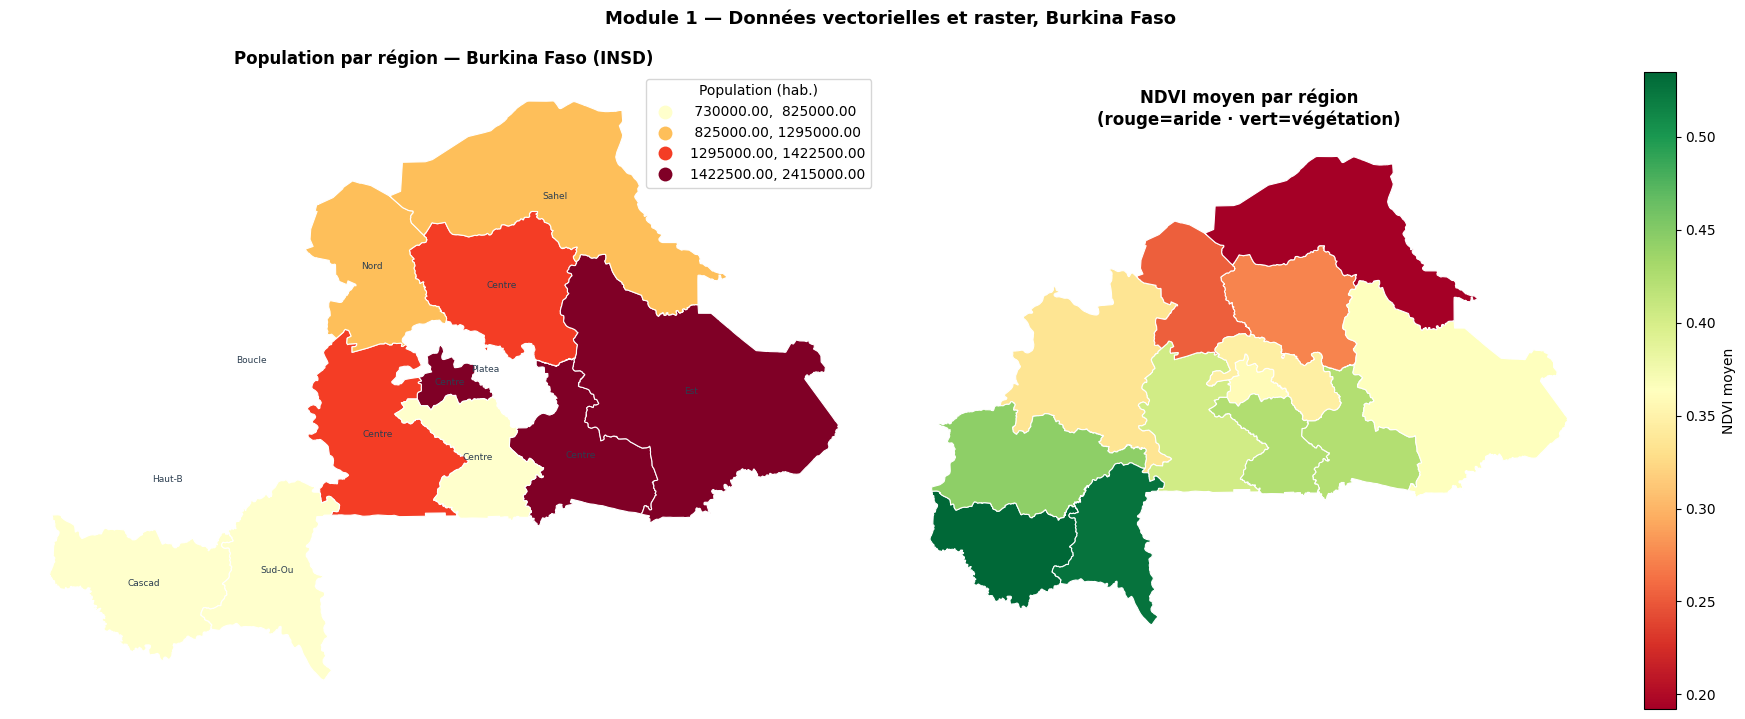

Carte sauvegardée : M1_cm_cartes_statiques.png


In [14]:
# OA5 + OA6 — Carte choroplèthe de la population par région BF

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Carte 1 : population
gdf.plot(
    column='population',
    cmap='YlOrRd',
    scheme='quantiles',   # classification : quantiles, equal_interval, jenks
    k=4,
    legend=True,
    legend_kwds={'title':'Population (hab.)'},
    edgecolor='white', linewidth=0.8,
    ax=axes[0]
)
axes[0].set_title('Population par région — Burkina Faso (INSD)',
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

# Annotation des noms de régions
for _, row in gdf.iterrows():
    c = row.geometry.centroid
    axes[0].annotate(row['region'][:6], xy=(c.x, c.y),
                     ha='center', va='center', fontsize=6.5, color='#2c3e50')

# Carte 2 : NDVI moyen
gdf.plot(
    column='ndvi_mean',
    cmap='RdYlGn',
    legend=True,
    legend_kwds={'label':'NDVI moyen','orientation':'vertical'},
    edgecolor='white', linewidth=0.8,
    ax=axes[1]
)
axes[1].set_title('NDVI moyen par région\n(rouge=aride · vert=végétation)',
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Module 1 — Données vectorielles et raster, Burkina Faso',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('M1_cm_cartes_statiques.png', dpi=150, bbox_inches='tight')
plt.show()
print('Carte sauvegardée : M1_cm_cartes_statiques.png')

## 6.2 Fond de carte avec Contextily

> ⚠️ Contextily requiert **EPSG:3857** (Web Mercator).
> Il faut toujours reprojeter le GeoDataFrame avant d'appeler `ctx.add_basemap()`.
> Les tuiles sont téléchargées depuis internet — nécessite une connexion.

Fond de carte chargé depuis CartoDB.


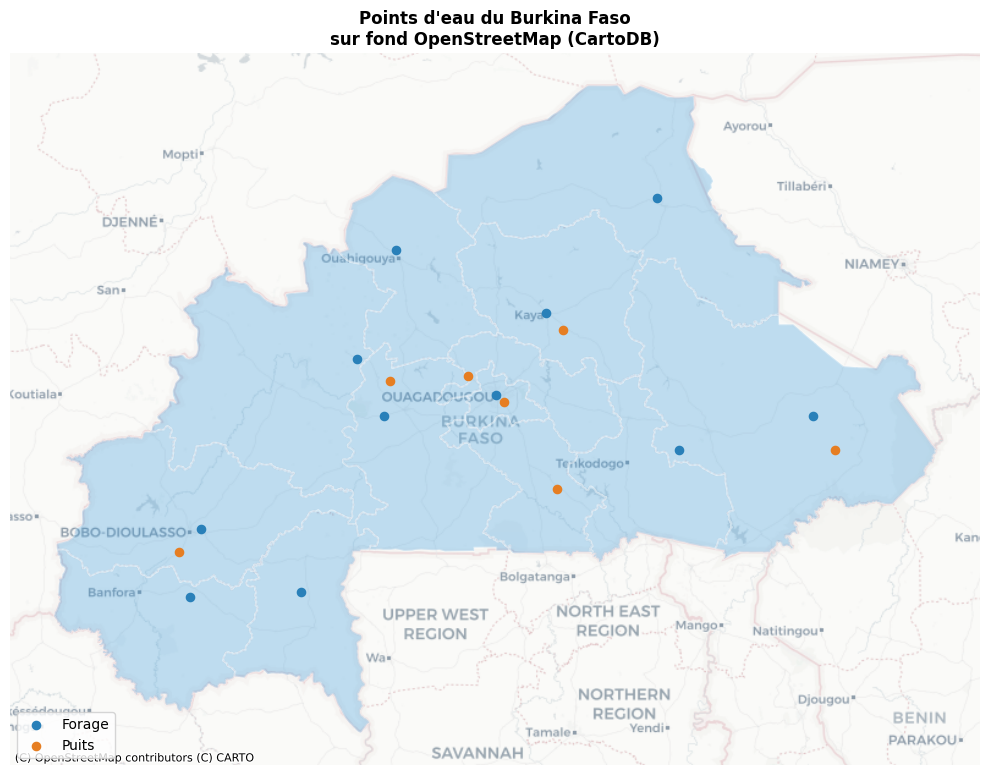

In [15]:
# OA5 + OA6 — Carte avec fond OpenStreetMap (Contextily)

fig, ax = plt.subplots(figsize=(10, 8))

# Reprojection en EPSG:3857 — obligatoire pour Contextily
gdf_web   = gdf.to_crs(epsg=3857)
puits_web = puits.to_crs(epsg=3857)

# Régions semi-transparentes
gdf_web.plot(ax=ax, alpha=0.3, edgecolor='white', linewidth=1.5, color='#3498db')

# Points d'eau colorés par type
couleurs = {'Forage':'#2980b9','Puits':'#e67e22'}
for ptype, color in couleurs.items():
    puits_web[puits_web['type']==ptype].plot(
        ax=ax, color=color, markersize=35, label=ptype, zorder=5)

# Fond OSM — requiert une connexion internet
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=7)
    print('Fond de carte chargé depuis CartoDB.')
except Exception as e:
    print(f'Fond de carte non disponible ({e}) — carte sans fond.')

ax.set_title('Points d\'eau du Burkina Faso\nsur fond OpenStreetMap (CartoDB)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.savefig('M1_cm_contextily.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 Carte interactive avec Folium

> Folium génère des cartes HTML interactives basées sur **Leaflet.js**.
> L'utilisateur peut zoomer, cliquer, survoler les polygones.
> Idéal pour les livrables destinés à des non-techniciens ou des interfaces web.

> ⚠️ Folium travaille **toujours en EPSG:4326** (WGS84).
> Ne jamais lui passer un GeoDataFrame en 32630 ou 3857.

> 💡 **Bonne pratique popup** : construire le HTML par concaténation de strings,
> jamais avec des f-strings triple-guillemets imbriqués dans du code notebook
> (risque de bug de syntaxe difficile à diagnostiquer).

In [16]:
# OA5 + OA6 — Carte interactive Folium

m = folium.Map(location=[12.37, -1.54], zoom_start=6, tiles='CartoDB positron')

# Couche choroplèthe population
geojson_str = gdf.to_json()
folium.Choropleth(
    geo_data=geojson_str,
    name='Population',
    data=gdf,
    columns=['region','population'],
    key_on='feature.properties.region',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.8,
    legend_name='Population par région (hab.)',
).add_to(m)

# Tooltips au survol — GeoJsonTooltip
folium.GeoJson(
    geojson_str,
    name='Infos régions',
    style_function=lambda x: {'fillOpacity':0,'color':'transparent'},
    tooltip=folium.GeoJsonTooltip(
        fields=['region','chef_lieu','population'],
        aliases=['Région :','Chef-lieu :','Population :'],
        localize=True
    )
).add_to(m)

# Marqueurs points d'eau — HTML popup par concaténation (jamais f-string triple-quote)
fg_puits = folium.FeatureGroup(name='Points d\'eau')
cfg = {'Forage':('blue','tint'),'Puits':('orange','circle')}
for _, row in puits.iterrows():
    col, ico = cfg.get(row['type'],('gray','info-sign'))
    popup_html = ('<b>' + str(row['nom']) + '</b><br>Type : ' + str(row['type']))
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=folium.Popup(popup_html, max_width=150),
        icon=folium.Icon(color=col, icon=ico, prefix='glyphicon'),
        tooltip=str(row['nom'])
    ).add_to(fg_puits)
fg_puits.add_to(m)

folium.LayerControl().add_to(m)
m.save('M1_cm_carte_interactive.html')
print('Carte interactive sauvegardée : M1_cm_carte_interactive.html')
m

Carte interactive sauvegardée : M1_cm_carte_interactive.html


---
# §7 — Bonnes Pratiques et Erreurs Fréquentes

> 🎯 **OA6** — Appliquer les bonnes pratiques sur des données réelles.

## 7.1 Structure de projet recommandée

```
projet_geo/
├── data/
│   ├── raw/        # Données brutes — jamais modifiées
│   ├── interim/    # Données en cours de traitement
│   └── processed/  # Résultats finaux
├── notebooks/
│   ├── 01_exploration.ipynb
│   ├── 02_traitement.ipynb
│   └── 03_visualisation.ipynb
├── src/            # Fonctions Python réutilisables
├── outputs/        # Cartes, rapports, exports
└── environment.yml # Dépendances conda
```

## 7.2 Les 8 erreurs les plus fréquentes

| # | Erreur | Conséquence | Correction |
|---|--------|-------------|-----------|
| 1 | Calculer `.area` en EPSG:4326 | Superficie en degrés² — absurde | `to_crs(32630)` avant |
| 2 | CRS différents avant `sjoin` | Résultats silencieusement faux | Vérifier `gdf.crs == puits.crs` |
| 3 | `src.read(0)` au lieu de `src.read(1)` | IndexError Rasterio | Les bandes commencent à **1** |
| 4 | Oublier `.astype(float)` avant NDVI | NDVI = 0 ou 1 partout | `.astype(float)` sur les bandes |
| 5 | Contextily sans EPSG:3857 | Carte décalée | `to_crs(3857)` avant `add_basemap()` |
| 6 | Déplacer `.shp` sans `.dbf/.shx/.prj` | Erreur de lecture | Utiliser GeoPackage |
| 7 | `key_on` Folium incorrect | Choropleth entièrement gris | Correspondance exacte avec GeoJSON |
| 8 | Popup HTML avec f-string triple-quote | Bug syntaxe silencieux | Concaténation de strings |

In [17]:
# OA6 — Fonction de vérification systématique d'un GeoDataFrame
# À utiliser après chaque chargement — 30 secondes qui évitent des heures de débogage

def check_gdf(gdf, name='GeoDataFrame'):
    print(f'=== {name} ===')
    print(f'  Shape     : {gdf.shape}')
    print(f'  CRS       : {gdf.crs}')
    print(f'  Geom type : {gdf.geometry.geom_type.value_counts().to_dict()}')
    print(f'  Nulles    : {gdf.isnull().sum().sum()} valeurs manquantes')
    invalides = (~gdf.is_valid).sum()
    print(f'  Invalides : {invalides} géométries invalides')
    print()

check_gdf(gdf,   'Régions BF')
check_gdf(puits, 'Points d\'eau')

=== Régions BF ===
  Shape     : (13, 22)
  CRS       : EPSG:4326
  Geom type : {'MultiPolygon': 13}
  Nulles    : 6 valeurs manquantes
  Invalides : 0 géométries invalides

=== Points d'eau ===
  Shape     : (18, 3)
  CRS       : EPSG:4326
  Geom type : {'Point': 18}
  Nulles    : 0 valeurs manquantes
  Invalides : 0 géométries invalides



---
# §8 — Synthèse et Connexion avec le Module 2

## Ce que vous avez appris et à quel objectif cela correspond

| Objectif | Compétence | Technique démontrée |
|----------|-----------|---------------------|
| **OA1** | Rôle de chaque bibliothèque | Tableau des bibliothèques + architecture |
| **OA2** | GeoDataFrame, sjoin, attributs | `gpd.from_features()`, `.sjoin()`, `.area` |
| **OA3** | Rasterio + NDVI | `rasterio.open()`, `.read(1)`, `.astype(float)` |
| **OA4** | CRS et reprojection | `to_crs(32630)`, démonstration erreur degrés² |
| **OA5** | Cartes statiques + interactives | `.plot()`, `contextily`, `folium.Choropleth` |
| **OA6** | Application BF | 13 régions, 18 points d'eau, NDVI, distances |

## Ce que ce module rend possible pour la suite

> Le **Module 2** (Feature Engineering Spatial) prend exactement là où ce module s'arrête :
> les GeoDataFrames des provinces BF et les rasters NDVI/FAPAR sont les **matières premières**
> à partir desquelles on va construire les features ML (lag spatial, distance aux routes,
> statistiques zonales, tendance FAPAR).

| Module 1 produit | Module 2 l'utilise pour |
|-----------------|------------------------|
| GeoDataFrame des régions/provinces | Base géométrique de W, VIF, feature matrix |
| Jointure sjoin | Compter les services par province |
| Rasterio + NDVI/FAPAR | Statistiques zonales → fapar_mean, fapar_trend |
| to_crs(32630) | Superficie, distance, buffer |
| Folium | Carte de résultats ML finale |